# Top-3 Analysis for Drivers and Constructors

In [1]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from src.data.data_preprocess import get_masterdata
from src.data.analysis import Top3Analyser

In [3]:
from src.data.data_preprocess import get_masterdata
from src.data.analysis import Top3Analyser

masterdata = get_masterdata()
analyser = Top3Analyser(masterdata)

 Merge step 1: on raceId → shape: (26759, 35)
 Merge step 2: on driverId → shape: (26759, 43)
 Merge step 3: on constructorId → shape: (26759, 47)
 Merge step 4: on ['raceId', 'driverId'] → shape: (26759, 54)


In [4]:
masterdata.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'race_position', 'positionText', 'positionOrder', 'points', 'laps',
       'race_time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'gp_name',
       'date', 'race_start', 'url_gp', 'fp1_date', 'fp1_time', 'fp2_date',
       'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time',
       'sprint_date', 'sprint_time', 'driverRef', 'code', 'forename',
       'surname', 'dob', 'driver_nationality', 'url_driver', 'constructorRef',
       'constructor_name', 'constructor_nationality', 'url_constructor',
       'qualifyId', 'qualifying_position', 'q1', 'q2', 'q3', 'top3'],
      dtype='object')

In [5]:
masterdata.head()

,resultId,raceId,driverId,constructorId,number,grid,race_position,positionText,positionOrder,points,...,constructorRef,constructor_name,constructor_nationality,url_constructor,qualifyId,qualifying_position,q1,q2,q3,top3
0,1,18,1,1,22,1,1.0,1,1,10.0,...,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,1.0,1.0,1:26.572,1:25.187,1:26.714,1
1,2,18,2,2,3,5,2.0,2,2,8.0,...,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,5.0,5.0,1:25.960,1:25.518,1:27.236,1
2,3,18,3,3,7,7,3.0,3,3,6.0,...,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,7.0,7.0,1:26.295,1:26.059,1:28.687,1
3,4,18,4,4,5,11,4.0,4,4,5.0,...,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,12.0,12.0,1:26.907,1:26.188,\N,0
4,5,18,5,1,23,3,5.0,5,5,4.0,...,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,3.0,3.0,1:25.664,1:25.452,1:27.079,0


In [6]:
drivers_top3 = analyser.analyse(
    group_col='driverRef',
    name_col='full_name',
    sort_by='count'
)


In [7]:
constructors_top3 = analyser.analyse(
    group_col='constructorRef',
    name_col='constructor_name',
    sort_by='count'
)

In [8]:
drivers_top3

,driverRef,top3_count,total_races,top3_percent,full_name
0,hamilton,202,356,56.741573,Lewis Hamilton
1,michael_schumacher,155,308,50.324675,Michael Schumacher
2,vettel,122,300,40.666667,Sebastian Vettel
3,max_verstappen,112,209,53.588517,Max Verstappen
4,alonso,106,404,26.237624,Fernando Alonso
...,...,...,...,...,...
856,griffith,0,3,0.000000,Cliff Griffith
857,grignard,0,1,0.000000,Georges Grignard
858,grim,0,2,0.000000,Bobby Grim
859,grouillard,0,62,0.000000,Olivier Grouillard


In [9]:
constructors_top3

,constructorRef,top3_count,total_races,top3_percent,constructor_name
0,ferrari,841,2439,34.481345,Ferrari
1,mclaren,508,1923,26.417057,McLaren
2,williams,313,1676,18.675418,Williams
3,mercedes,298,652,45.705521,Mercedes
4,red_bull,282,788,35.786802,Red Bull
...,...,...,...,...,...
206,iso_marlboro,0,55,0.000000,Iso Marlboro
207,jbw,0,6,0.000000,JBW
208,kauhsen,0,2,0.000000,Kauhsen
209,klenk,0,1,0.000000,Klenk


In [10]:
drivers_top3_clean = drivers_top3[drivers_top3['top3_count'] > 0]
constructors_top3_clean = constructors_top3[constructors_top3['top3_count'] > 0]

In [12]:
from src.data.data_visualize import plot_bar


<Figure size 1400x600 with 0 Axes>

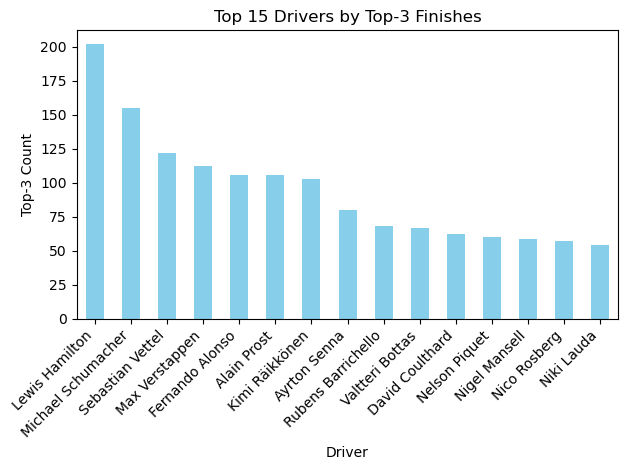

In [13]:
plot_bar(drivers_top3_clean.head(15), 'full_name', 'top3_count',
         title='Top 15 Drivers by Top-3 Finishes',
         xlabel='Driver',
         ylabel='Top-3 Count')

<Figure size 1400x600 with 0 Axes>

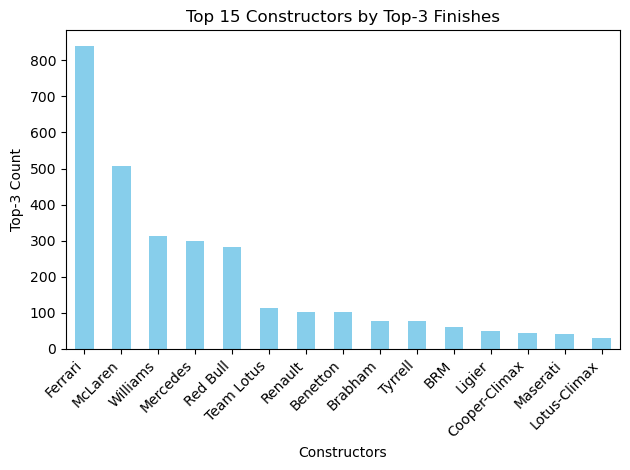

In [14]:
plot_bar(constructors_top3_clean.head(15), 'constructor_name', 'top3_count',
         title='Top 15 Constructors by Top-3 Finishes',
         xlabel='Constructors',
         ylabel='Top-3 Count')

## Driver-constructor

In [15]:
from src.data.features_engineering import top3_by_driver_constructor

driver_team_top3 = top3_by_driver_constructor(masterdata)
driver_team_top3.head(20)

,full_name,constructor_name,top3_count,total_races,top3_percent
0,Lewis Hamilton,Mercedes,153,246,62.195122
1,Michael Schumacher,Ferrari,116,181,64.088398
2,Max Verstappen,Red Bull,112,186,60.215054
3,Sebastian Vettel,Red Bull,65,113,57.522124
4,Alain Prost,McLaren,63,109,57.798165
5,Valtteri Bottas,Mercedes,58,101,57.425743
6,Rubens Barrichello,Ferrari,55,104,52.884615
7,Ayrton Senna,McLaren,55,96,57.291667
8,Nico Rosberg,Mercedes,55,136,40.441176
9,Sebastian Vettel,Ferrari,55,119,46.218487
